## Load Library

In [1]:
import os
import numpy as np
import pandas as pd
from scipy import signal, stats
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from torchsummary import summary

import time
import pickle
from sklearn.metrics import r2_score
import statsmodels.api as sm
from scipy.signal import hilbert

import warnings
warnings.filterwarnings("ignore", category=RuntimeWarning, module="networkx.utils.backends")

## Training parameters

In [2]:
num_epochs = 100
save_every = 100
learning_rate = 0.001
batch_size = 32
model_num = 12
num_samples = 4381   # Keep simulated data, upsample experimental data
duration = 10.33
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

## Load and processing data

### Simulated data

In [3]:
# Load cvs file and convert it to numpy
data_dir = 'C:\Research\Radar Signal Domain Adaptation\Two_Layer'
fname = os.path.join(data_dir, '2_layer_SimData_1033.csv')
SimData = pd.read_csv(fname).to_numpy()

In [4]:
# Seperate data and label
Sim_Data = SimData[:,6:]
Sim_Label = SimData[:,0:6]

# Simulation time
sim_time_range = 10.33
sim_num_samples = 4381
SimTime = np.arange(sim_time_range/sim_num_samples,sim_time_range+sim_time_range/sim_num_samples,sim_time_range/sim_num_samples)

In [5]:
# Fine the index given specific labels
def find_index(d1):
    d1_idx = np.where(Sim_Label[:,2]==d1)
    return d1_idx
    
find_index(0.15)

(array([   36,    37,    38, ..., 49641, 49642, 49643], dtype=int64),)

In [6]:
# Select from simulated dataset
SimTrain_Data = Sim_Data[find_index(0.15)]
SimTrain_Label_All = Sim_Label[find_index(0.15)]
SimTrain_Label = np.delete(SimTrain_Label_All, obj=2, axis=1)  # delete d1 lable

In [7]:
# Check data size
print(SimTrain_Data.shape)
print(SimTrain_Label.shape)

(16560, 4381)
(16560, 5)


### Experimental data

In [8]:
# Experimental time 
exp_time_range = 10.33
exp_num_samples = 512
ExpTime = np.arange(exp_time_range/exp_num_samples,exp_time_range+exp_time_range/exp_num_samples,exp_time_range/exp_num_samples)[:-2]

In [9]:
# Experimental radar signals
# Load cvs file and convert it to numpy
data_dir = 'C:\Research\Radar Signal Domain Adaptation\Two_Layer'
fnum = 284
fname = os.path.join(data_dir, f'FILE__%d.CSV' % fnum)
data = pd.read_csv(fname, header=None).to_numpy()
test_1_data = data[300:350]

fnum = 285
fname = os.path.join(data_dir, f'FILE__%d.CSV' % fnum)
data = pd.read_csv(fname, header=None).to_numpy()
test_2_data = data[25:75]
test_3_data = data[225:275]

fnum = 286
fname = os.path.join(data_dir, f'FILE__%d.CSV' % fnum)
data = pd.read_csv(fname, header=None).to_numpy()
test_4_data = data[325:375]
test_5_data = data[525:575]
test_6_data = data[760:810]    # fix location 825:875     moving location 760:810

fnum = 287
fname = os.path.join(data_dir, f'FILE__%d.CSV' % fnum)
data = pd.read_csv(fname, header=None).to_numpy()
test_7_data = data[375:425]    # fix location 525:575     moving location 375:425
test_8_data = data[900:950]    # fix location 825:875     moving location 900:950
test_9_data = data[1150:1200]  # fix location 1225:1275   moving location 1150:1200

fnum = 288
fname = os.path.join(data_dir, f'FILE__%d.CSV' % fnum)
data = pd.read_csv(fname, header=None).to_numpy()
test_10_data = data[425:475]
test_11_data = data[725:775]
test_12_data = data[1025:1075]

fnum = 289
fname = os.path.join(data_dir, f'FILE__%d.CSV' % fnum)
data = pd.read_csv(fname, header=None).to_numpy()
test_13_data = data[350:400]   # fix location 450:500     moving location 350:400
test_14_data = data[700:750]   # fix location 800:850     moving location 700:750
test_15_data = data[1050:1100] # fix location 1125:1175   moving location 1050:1100

fnum = 290
fname = os.path.join(data_dir, f'FILE__%d.CSV' % fnum)
data = pd.read_csv(fname, header=None).to_numpy()
test_16_data = data[310:360]   # fix location 400:450     moving location 310:360
test_17_data = data[500:550]   # fix location 825:875     moving location 500:550
test_18_data = data[1080:1130] # fix location 1175:1225   moving location 1080:1130

ExpTest_Data = np.concatenate((test_1_data, test_2_data, test_3_data, test_4_data, test_5_data, test_6_data,
                               test_7_data, test_8_data, test_9_data, test_10_data, test_11_data, test_12_data,
                               test_13_data, test_14_data, test_15_data, test_16_data, test_17_data, test_18_data), axis=0)

In [10]:
# Experimental labels
# Load excel file and convert it to numpy
fname = os.path.join(data_dir, 'Test_Summary.xlsx')
label = pd.read_excel(fname,sheet_name='Sheet2')
ExpTest_Label_All = np.repeat(label.iloc[:, 1:].to_numpy(),repeats=50, axis=0)
ExpTest_Label = np.delete(ExpTest_Label_All, obj=2, axis=1)   # delete d1 lable

In [11]:
# Check data size
print(ExpTest_Label.shape)
print(ExpTest_Data.shape)

(900, 5)
(900, 510)


### Processing dataset

In [12]:
# Process the signal to ensure a consistent duration and number of samples
def signal_processing(input_signal, time, duration, num_samples):
    idx = (np.abs(time - duration)).argmin()                       # Find the index corresponding to the specified duration
    truncate_siganl = input_signal[0:idx]                          # Truncate the signal to the specified duration
    output_signal = signal.resample(truncate_siganl, num_samples)  # Generate the signal with the specified number of samples
    return output_signal

# Normalize the signal using max normalization
def norm(input_signal):
    input_signal = input_signal/np.max(input_signal)
    return input_signal

# Shift the signal along Y-axis
def Yshift(input_signal):
    input_signal = input_signal-np.mean(input_signal)
    return input_signal

# Shift the signal along X-axis to ensure the same start time in both simulated and experimental signals
def Xshift(sim_signal, exp_signal, sim_time, exp_time):
    sim_max_index = np.argmax(sim_signal)       # Find the index of the maximum value of simulated signal
    sim_max_time = sim_time[sim_max_index]      # Find the time of the maximum value of simulated signal
    exp_max_index = np.argmax(exp_signal)       # Find the index of the maximum value of experimental signal
    exp_max_time = exp_time[exp_max_index]      # Find the time of the maximum value of experimental signal
    time_diff = exp_max_time-sim_max_time       # Calcualte the time difference between simulated and experimental signals
    shift_index = np.absolute(exp_time-time_diff).argmin()    # Find the index of where the experimental signal should start
    exp_signal_shift = exp_signal[shift_index:]               # Remove the samples at the begining of the experimental signal
    exp_time_shift = exp_time[:len(exp_time)-shift_index]     # Update the time vector of the experimental signal
    return exp_signal_shift, exp_time_shift

In [13]:
ExpTest_Data_Pro = np.zeros((ExpTest_Data.shape[0],num_samples))
SimTrain_Data_Pro = SimTrain_Data    # Simulated data already normalized

# Keep simulated data, upsample experimental data
for i in range(ExpTest_Data.shape[0]):
    exp_signal_shift, exp_time_shift = Xshift(SimTrain_Data[0], np.abs(hilbert(Yshift(ExpTest_Data[i]))), SimTime, ExpTime)
    ExpTest_Data_Pro[i] = norm(signal_processing(exp_signal_shift, exp_time_shift, duration, num_samples))

In [14]:
# Normalize the training labels
SimTrain_Label_Pro = np.zeros((SimTrain_Label.shape))

for i in range(SimTrain_Label.shape[1]):
    SimTrain_Label_Pro[:,i] = (SimTrain_Label[:,i] - np.min(SimTrain_Label[:,i])) /\
        (np.max(SimTrain_Label[:,i]) - np.min(SimTrain_Label[:,i]))

In [15]:
# Check data size
print(SimTrain_Data_Pro.shape)
print(SimTrain_Label_Pro.shape)
print(ExpTest_Data_Pro.shape)
print(ExpTest_Label.shape)


(16560, 4381)
(16560, 5)
(900, 4381)
(900, 5)


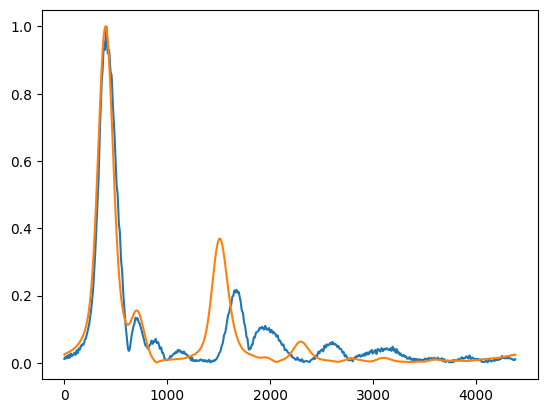

In [16]:
plt.plot(ExpTest_Data_Pro[100])
plt.plot(SimTrain_Data_Pro[0])

### Build data loader

In [17]:
# Train loader
SimTrain_Data_Pro_Tensor = torch.tensor(SimTrain_Data_Pro, dtype=torch.float32)
SimTrain_Label_Pro_Tensor = torch.tensor(SimTrain_Label_Pro, dtype=torch.float32)
Train_Dataset = TensorDataset(SimTrain_Data_Pro_Tensor,SimTrain_Label_Pro_Tensor)
Train_Loader = DataLoader(Train_Dataset, batch_size, shuffle=True)

## Build regression model

In [18]:
class ConvRegression(nn.Module):
    def __init__(self):
        super(ConvRegression, self).__init__()
        
        self.features = nn.Sequential(
            
            # input shape: 1 x 4381
            nn.Conv1d(in_channels=1, out_channels=32, kernel_size=5, stride=5, bias=False),
            # output shape: 32 x 876
            nn.BatchNorm1d(32),
            nn.LeakyReLU(0.1, inplace=True),
            
            nn.Conv1d(in_channels=32, out_channels=64, kernel_size=5, stride=5, bias=False),
            # output shape: 64 x 175
            nn.BatchNorm1d(64),
            nn.LeakyReLU(0.1, inplace=True),
            
            nn.Conv1d(in_channels=64, out_channels=128, kernel_size=4, stride=4, bias=False),
            # output shape: 128 x 43
            nn.BatchNorm1d(128),
            nn.LeakyReLU(0.1, inplace=True),
            
            nn.Conv1d(in_channels=128, out_channels=256, kernel_size=4, stride=4, bias=False),
            # output shape: 256 x 10
            nn.BatchNorm1d(256),
            nn.LeakyReLU(0.1, inplace=True),
            
            nn.Conv1d(in_channels=256, out_channels=512, kernel_size=3, stride=3, bias=False),
            # output shape: 512 x 3
            nn.BatchNorm1d(512),
            nn.LeakyReLU(0.1, inplace=True),
            
            nn.Conv1d(in_channels=512, out_channels=10240, kernel_size=3, stride=3, bias=False),
            # output shape: 10240 x 1
            nn.BatchNorm1d(10240),
            nn.LeakyReLU(0.1, inplace=True),
        )
        
        self.classifier = nn.Sequential(
            
            nn.Flatten(),
            nn.Linear(10240, 5)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

In [19]:
model = ConvRegression().to(device)
summary(model, (1,num_samples))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv1d-1              [-1, 32, 876]             160
       BatchNorm1d-2              [-1, 32, 876]              64
         LeakyReLU-3              [-1, 32, 876]               0
            Conv1d-4              [-1, 64, 175]          10,240
       BatchNorm1d-5              [-1, 64, 175]             128
         LeakyReLU-6              [-1, 64, 175]               0
            Conv1d-7              [-1, 128, 43]          32,768
       BatchNorm1d-8              [-1, 128, 43]             256
         LeakyReLU-9              [-1, 128, 43]               0
           Conv1d-10              [-1, 256, 10]         131,072
      BatchNorm1d-11              [-1, 256, 10]             512
        LeakyReLU-12              [-1, 256, 10]               0
           Conv1d-13               [-1, 512, 3]         393,216
      BatchNorm1d-14               [-1,

## Compile and train regression model

In [20]:
# Instantiate and train
model = ConvRegression().to(device)
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=learning_rate)

In [21]:
def _save_checkpoint(epoch):
    ckp = model.state_dict()
    path = f'./Saved_Model/CNN_Model_{model_num}/checkpoint_{epoch+1}.pt'
    torch.save(ckp, path)
    with open(f'./Saved_Model/CNN_Model_{model_num}/trainHistoryDict_{epoch+1}', 'wb') as file_pi:
        pickle.dump(loss_hist, file_pi)
    print(f'Epoch {epoch+1} | Training checkpoint saved at {path}')

In [22]:
# Training loop
start_time = time.time()
loss_hist = []

for epoch in range(num_epochs):
    model.train()
    epoch_loss = 0.0
    for batch_x, batch_y in Train_Loader:
        batch_x = torch.unsqueeze(batch_x,1).to(device)
        batch_y = batch_y.to(device)
        output = model(batch_x)
        loss = criterion(output, batch_y)
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()

    print(f"Epoch {epoch+1}/{num_epochs}, Loss: {epoch_loss/len(Train_Loader):.6f}")
    loss_hist.append(epoch_loss)
            
    if save_every is not None and (epoch+1) % save_every == 0:
        _save_checkpoint(epoch)

end_time = time.time()
print(f"Training time: {(end_time - start_time) / 60:.1f} min")

Epoch 1/100, Loss: 0.218598
Epoch 2/100, Loss: 0.071812
Epoch 3/100, Loss: 0.066179
Epoch 4/100, Loss: 0.052314
Epoch 5/100, Loss: 0.060157
Epoch 6/100, Loss: 0.032420
Epoch 7/100, Loss: 0.031915
Epoch 8/100, Loss: 0.018360
Epoch 9/100, Loss: 0.021508
Epoch 10/100, Loss: 0.011275
Epoch 11/100, Loss: 0.009484
Epoch 12/100, Loss: 0.010272
Epoch 13/100, Loss: 0.021415
Epoch 14/100, Loss: 0.007796
Epoch 15/100, Loss: 0.007377
Epoch 16/100, Loss: 0.007267
Epoch 17/100, Loss: 0.007041
Epoch 18/100, Loss: 0.006232
Epoch 19/100, Loss: 0.006104
Epoch 20/100, Loss: 0.005949
Epoch 21/100, Loss: 0.004905
Epoch 22/100, Loss: 0.004871
Epoch 23/100, Loss: 0.004507
Epoch 24/100, Loss: 0.004224
Epoch 25/100, Loss: 0.003361
Epoch 26/100, Loss: 0.003307
Epoch 27/100, Loss: 0.002967
Epoch 28/100, Loss: 0.002928
Epoch 29/100, Loss: 0.002427
Epoch 30/100, Loss: 0.002435
Epoch 31/100, Loss: 0.002537
Epoch 32/100, Loss: 0.002191
Epoch 33/100, Loss: 0.002142
Epoch 34/100, Loss: 0.002110
Epoch 35/100, Loss: 0.0

## Test loss curve

In [20]:
Test_R_all = np.zeros((int(num_epochs/save_every),1))

for j in range(int(num_epochs/save_every)):
    
    # Load trained autoencoder
    model.load_state_dict(torch.load(f'./Saved_Model/CNN_Model_{model_num}/checkpoint_{(j+1)*100}.pt'))
    
    # Evaluate using the validation dataset
    model.eval()
    with torch.no_grad():
        ExpTest_Pred_Pro = model(torch.unsqueeze(torch.tensor(ExpTest_Data_Pro, dtype=torch.float32),1).to(device))
    ExpTest_Pred_Pro = ExpTest_Pred_Pro.cpu().numpy()

    # De-normalize the predictions
    ExpTest_Pred = np.zeros((ExpTest_Pred_Pro.shape))

    for i in range(ExpTest_Pred_Pro.shape[1]):
        ExpTest_Pred[:,i] = ExpTest_Pred_Pro[:,i] * \
            (np.max(SimTrain_Label[:,i]) - np.min(SimTrain_Label[:,i])) + np.min(SimTrain_Label[:,i])
    
    # Calculate R
    Test_R_all[j] = np.corrcoef(ExpTest_Label[:,0].astype(float), ExpTest_Pred[:,0].astype(float))[0,1]

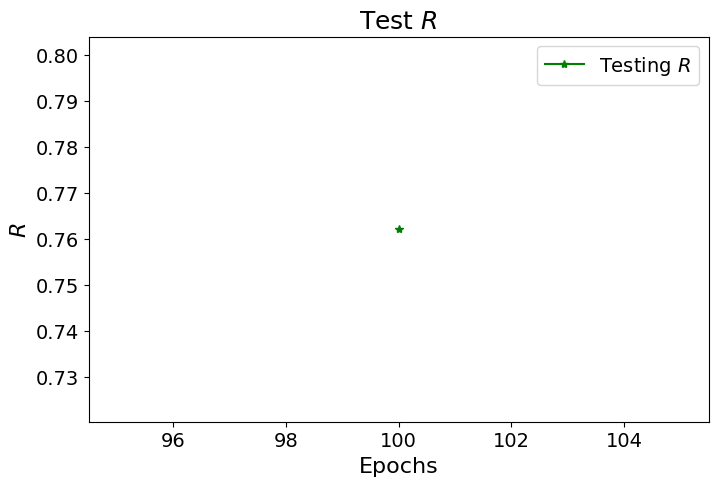

The highest test R is achieved at Epoch: 100


In [21]:
fig = plt.figure(figsize=(8, 5))
plt.plot(range(100,num_epochs+1,100), Test_R_all, 'g-*', label='Testing $R$')
plt.title('Test $R$',fontsize=18)
plt.xlabel('Epochs',fontsize=16)
plt.ylabel('$R$',fontsize=16)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.legend(fontsize=14)
plt.show()

epoch = int((np.where(Test_R_all == Test_R_all.max())[0][0] + 1) * 100)
print(f'The highest test R is achieved at Epoch: {epoch}')

## Load trained regression model

In [22]:
select_epochs = 100

In [23]:
# Load trained autoencoder
model.load_state_dict(torch.load(f'./Saved_Model/CNN_Model_{model_num}/checkpoint_{select_epochs}.pt'))

# Load train history
with open(f'./Saved_Model/CNN_Model_{model_num}/trainHistoryDict_{select_epochs}', 'rb') as file_pi:
        loss_hist = pickle.load(file_pi)

## Evaluate using experimental tesing dataset

In [24]:
# Evaluate using the experimental testing dataset
model.eval()

start_time = time.time()

with torch.no_grad():
    ExpTest_Pred_Pro = model(torch.unsqueeze(torch.tensor(ExpTest_Data_Pro, dtype=torch.float32),1).to(device))
ExpTest_Pred_Pro = ExpTest_Pred_Pro.cpu().numpy()

end_time = time.time()
print(f"Inference time per scan: {(end_time - start_time)/ExpTest_Pred_Pro.shape[0]:.6f} sec")
    
# De-normalize the predictions
ExpTest_Pred = np.zeros((ExpTest_Pred_Pro.shape))

for i in range(ExpTest_Pred_Pro.shape[1]):
    ExpTest_Pred[:,i] = ExpTest_Pred_Pro[:,i] * \
        (np.max(SimTrain_Label[:,i]) - np.min(SimTrain_Label[:,i])) + np.min(SimTrain_Label[:,i])

# Mean square error
ExpTest_MSE_p1 = np.mean((ExpTest_Pred[:,0] - ExpTest_Label[:,0]) ** 2)
print('p1 MSE on experimental tesing dataset: %.10f' % (ExpTest_MSE_p1))

# R^2
ExpTest_R2_p1 = r2_score(ExpTest_Label[:,0], ExpTest_Pred[:,0])
print('p1 R2 on experimental tesing dataset: %.10f' % (ExpTest_R2_p1))

# R
ExpTest_R_p1 = np.corrcoef(ExpTest_Label[:,0].astype(float), ExpTest_Pred[:,0].astype(float))[0,1]
print('p1 R on experimental tesing dataset: %.10f' % (ExpTest_R_p1))

# Bias
ExpTest_Bias_p1 = np.mean(ExpTest_Pred[:,0]) - np.mean(ExpTest_Label[:,0])
print('p1 Bias on experimental tesing dataset: %.10f' % (ExpTest_Bias_p1))

Inference time per scan: 0.000011 sec
p1 MSE on experimental tesing dataset: 4.0951493140
p1 R2 on experimental tesing dataset: 0.5763151647
p1 R on experimental tesing dataset: 0.7620992001
p1 Bias on experimental tesing dataset: -0.2011000284


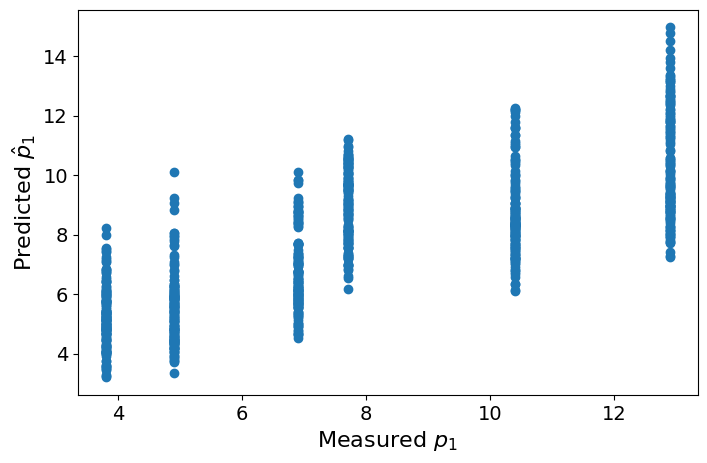

In [25]:
fig = plt.figure(figsize=(8, 5))
plt.scatter(ExpTest_Label[:,0],ExpTest_Pred[:,0])
plt.xlabel('Measured $p_1$',fontsize=16)
plt.ylabel('Predicted $\hat{p}_1$',fontsize=16)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.show()

In [26]:
# Mean square error
ExpTest_MSE_c1 = np.mean((ExpTest_Pred[:,1] - ExpTest_Label[:,1]) ** 2)
print('c1 MSE on experimental tesing dataset: %.10f' % (ExpTest_MSE_c1))

# R^2
ExpTest_R2_c1 = r2_score(ExpTest_Label[:,1], ExpTest_Pred[:,1])
print('c1 R2 on experimental tesing dataset: %.10f' % (ExpTest_R2_c1))

# R
ExpTest_R_c1 = np.corrcoef(ExpTest_Label[:,1].astype(float), ExpTest_Pred[:,1].astype(float))[0,1]
print('c1 R on experimental tesing dataset: %.10f' % (ExpTest_R_c1))

# Bias
ExpTest_Bias_c1 = np.mean(ExpTest_Pred[:,1]) - np.mean(ExpTest_Label[:,1])
print('c1 Bias on experimental tesing dataset: %.10f' % (ExpTest_Bias_c1))

c1 MSE on experimental tesing dataset: 0.0026157764
c1 R2 on experimental tesing dataset: -0.7670357276
c1 R on experimental tesing dataset: 0.4514593264
c1 Bias on experimental tesing dataset: -0.0378292443


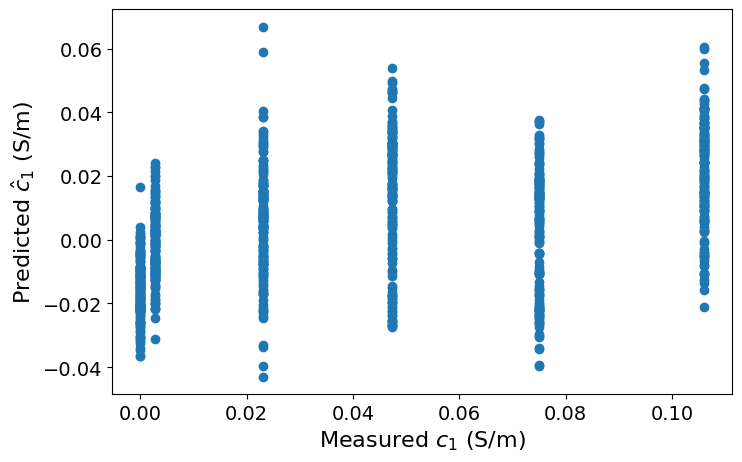

In [27]:
fig = plt.figure(figsize=(8, 5))
plt.scatter(ExpTest_Label[:,1],ExpTest_Pred[:,1])
plt.xlabel('Measured $c_1$ (S/m)',fontsize=16)
plt.ylabel('Predicted $\hat{c}_1$ (S/m)',fontsize=16)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.show()

In [28]:
# Mean square error
ExpTest_MSE_p2 = np.mean((ExpTest_Pred[:,2] - ExpTest_Label[:,2]) ** 2)
print('p2 MSE on experimental tesing dataset: %.10f' % (ExpTest_MSE_p2))

# R^2
ExpTest_R2_p2 = r2_score(ExpTest_Label[:,2], ExpTest_Pred[:,2])
print('p2 R2 on experimental tesing dataset: %.10f' % (ExpTest_R2_p2))

# R
ExpTest_R_p2 = np.corrcoef(ExpTest_Label[:,2].astype(float), ExpTest_Pred[:,2].astype(float))[0,1]
print('p2 R on experimental tesing dataset: %.10f' % (ExpTest_R_p2))

# Bias
ExpTest_Bias_p2 = np.mean(ExpTest_Pred[:,2]) - np.mean(ExpTest_Label[:,2])
print('p2 Bias on experimental tesing dataset: %.10f' % (ExpTest_Bias_p2))

p2 MSE on experimental tesing dataset: 0.6571601132
p2 R2 on experimental tesing dataset: -1.0536253536
p2 R on experimental tesing dataset: 0.0842377756
p2 Bias on experimental tesing dataset: -0.4534512060


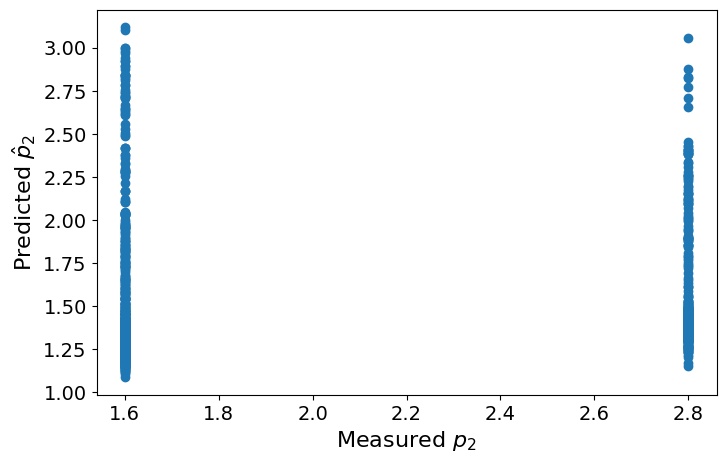

In [29]:
fig = plt.figure(figsize=(8, 5))
plt.scatter(ExpTest_Label[:,2],ExpTest_Pred[:,2])
plt.xlabel('Measured $p_2$',fontsize=16)
plt.ylabel('Predicted $\hat{p}_2$',fontsize=16)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.show()

In [30]:
# Mean square error
ExpTest_MSE_c2 = np.mean((ExpTest_Pred[:,3] - ExpTest_Label[:,3]) ** 2)
print('c2 MSE on experimental tesing dataset: %.10f' % (ExpTest_MSE_c2))

# R^2
ExpTest_R2_c2 = r2_score(ExpTest_Label[:,3], ExpTest_Pred[:,3])
print('c2 R2 on experimental tesing dataset: %.10f' % (ExpTest_R2_c2))

# R
ExpTest_R_c2 = np.corrcoef(ExpTest_Label[:,3].astype(float), ExpTest_Pred[:,3].astype(float))[0,1]
print('c2 R on experimental tesing dataset: %.10f' % (ExpTest_R_c2))

# Bias
ExpTest_Bias_c2 = np.mean(ExpTest_Pred[:,3]) - np.mean(ExpTest_Label[:,3])
print('c2 Bias on experimental tesing dataset: %.10f' % (ExpTest_Bias_c2))

c2 MSE on experimental tesing dataset: 0.0000637631
c2 R2 on experimental tesing dataset: 0.0000000000
c2 R on experimental tesing dataset: nan
c2 Bias on experimental tesing dataset: -0.0010485961


c:\Users\wangz\anaconda3\envs\pytorch\lib\site-packages\numpy\lib\function_base.py:2897: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
c:\Users\wangz\anaconda3\envs\pytorch\lib\site-packages\numpy\lib\function_base.py:2898: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


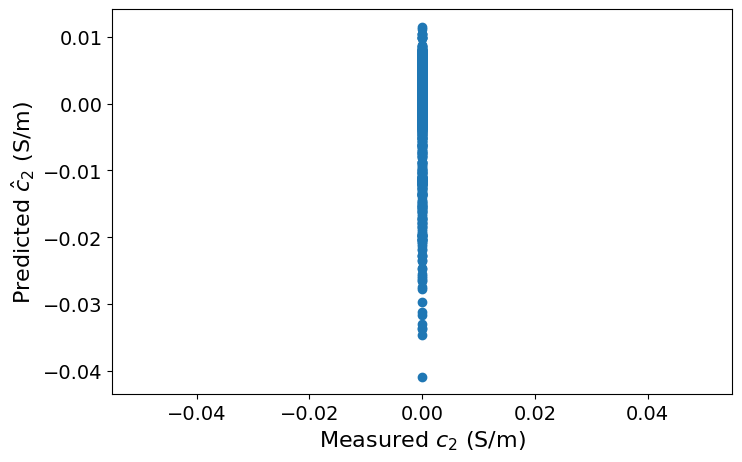

In [31]:
fig = plt.figure(figsize=(8, 5))
plt.scatter(ExpTest_Label[:,3],ExpTest_Pred[:,3])
plt.xlabel('Measured $c_2$ (S/m)',fontsize=16)
plt.ylabel('Predicted $\hat{c}_2$ (S/m)',fontsize=16)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.show()

In [32]:
# Mean square error
ExpTest_MSE_d2 = np.mean((ExpTest_Pred[:,4] - ExpTest_Label[:,4]) ** 2)
print('d2 MSE on experimental tesing dataset: %.10f' % (ExpTest_MSE_d2))

# R^2
ExpTest_R2_d2 = r2_score(ExpTest_Label[:,4], ExpTest_Pred[:,4])
print('d2 R2 on experimental tesing dataset: %.10f' % (ExpTest_R2_d2))

# R
ExpTest_R_d2 = np.corrcoef(ExpTest_Label[:,4].astype(float), ExpTest_Pred[:,4].astype(float))[0,1]
print('d2 R on experimental tesing dataset: %.10f' % (ExpTest_R_d2))

# Bias
ExpTest_Bias_d2 = np.mean(ExpTest_Pred[:,4]) - np.mean(ExpTest_Label[:,4])
print('d2 Bias on experimental tesing dataset: %.10f' % (ExpTest_Bias_d2))

d2 MSE on experimental tesing dataset: 0.0026294108
d2 R2 on experimental tesing dataset: -3.7329395040
d2 R on experimental tesing dataset: 0.0296588949
d2 Bias on experimental tesing dataset: 0.0308975569


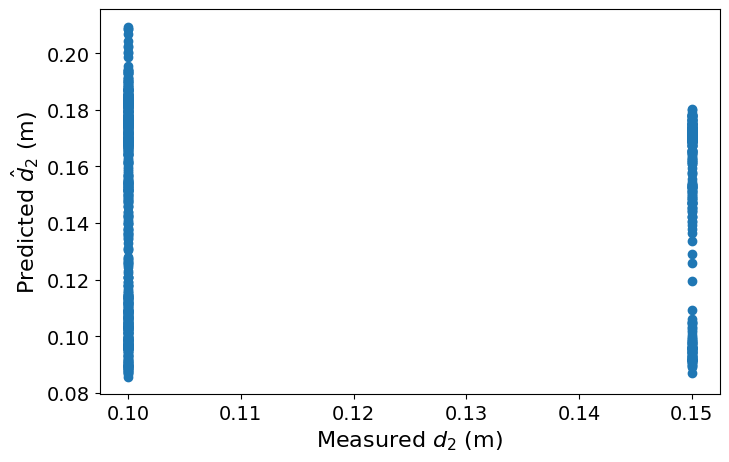

In [33]:
fig = plt.figure(figsize=(8, 5))
plt.scatter(ExpTest_Label[:,4],ExpTest_Pred[:,4])
plt.xlabel('Measured $d_2$ (m)',fontsize=16)
plt.ylabel('Predicted $\hat{d}_2$ (m)',fontsize=16)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.show()

## Information fusion

### Soil permittivity

In [34]:
specimen_1_pred_mean_p1 = np.mean(ExpTest_Pred[0:150,0])
specimen_2_pred_mean_p1 = np.mean(ExpTest_Pred[150:300,0])
specimen_3_pred_mean_p1 = np.mean(ExpTest_Pred[300:450,0])
specimen_4_pred_mean_p1 = np.mean(ExpTest_Pred[450:600,0])
specimen_5_pred_mean_p1 = np.mean(ExpTest_Pred[600:750,0])
specimen_6_pred_mean_p1 = np.mean(ExpTest_Pred[750:900,0])
ExpTest_Pred_Pro_p1 = np.array([specimen_1_pred_mean_p1,specimen_2_pred_mean_p1,specimen_3_pred_mean_p1,
                                    specimen_4_pred_mean_p1,specimen_5_pred_mean_p1,specimen_6_pred_mean_p1])
ExpTest_Label_Pro_p1 = np.array([ExpTest_Label[0,0],ExpTest_Label[150,0],ExpTest_Label[300,0],
                                    ExpTest_Label[450,0],ExpTest_Label[600,0],ExpTest_Label[750,0]])

In [35]:
# R^2
ExpTest_R2_p1 = r2_score(ExpTest_Label_Pro_p1,ExpTest_Pred_Pro_p1)
print('p1 R2 on experimental tesing dataset: %.10f' % (ExpTest_R2_p1))

# Mean square error
ExpTest_MSE_p1 = np.mean((ExpTest_Pred_Pro_p1 - ExpTest_Label_Pro_p1) ** 2)
print('p1 MSE on experimental tesing dataset: %.10f' % (ExpTest_MSE_p1))

# R
ExpTest_R_p1 = np.corrcoef(ExpTest_Label_Pro_p1,ExpTest_Pred_Pro_p1)[0,1]
print('p1 R on experimental tesing dataset: %.10f' % (ExpTest_R_p1))

# Bias
ExpTest_Bias_p1 = np.mean(ExpTest_Pred_Pro_p1) - np.mean(ExpTest_Label_Pro_p1)
print('p1 Bias on experimental tesing dataset: %.10f' % (ExpTest_Bias_p1))

p1 R2 on experimental tesing dataset: 0.7654825483
p1 MSE on experimental tesing dataset: 2.2667414585
p1 R on experimental tesing dataset: 0.9387355461
p1 Bias on experimental tesing dataset: -0.2011000284


p1 R on experimental tesing dataset: 0.9387355461
p1 Bias on experimental tesing dataset: -0.2011000284
p1 MSE on experimental tesing dataset: 2.2667414585
p1 RMSE on experimental tesing dataset: 1.5055701440
p1 ubMSE on experimental tesing dataset: 1.4920791658


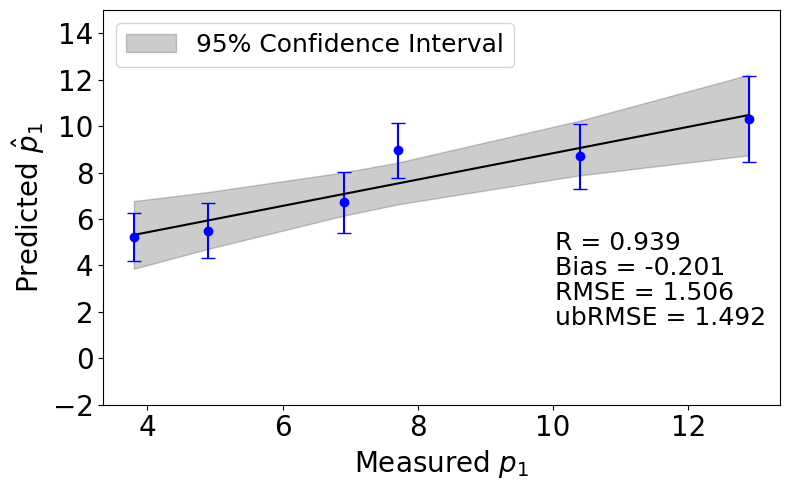

In [36]:
# Mean of predictions
mean_1 = np.mean(ExpTest_Pred[0:150,0])
mean_2 = np.mean(ExpTest_Pred[150:300,0])
mean_3 = np.mean(ExpTest_Pred[300:450,0])
mean_4 = np.mean(ExpTest_Pred[450:600,0])
mean_5 = np.mean(ExpTest_Pred[600:750,0])
mean_6 = np.mean(ExpTest_Pred[750:900,0])

# Standard deviation of predictions
std_1 = np.std(ExpTest_Pred[0:150,0])
std_2 = np.std(ExpTest_Pred[150:300,0])
std_3 = np.std(ExpTest_Pred[300:450,0])
std_4 = np.std(ExpTest_Pred[450:600,0])
std_5 = np.std(ExpTest_Pred[600:750,0])
std_6 = np.std(ExpTest_Pred[750:900,0])

pred_mean = np.array([mean_1,mean_2,mean_3,mean_4,mean_5,mean_6])
std_mean = np.array([std_1,std_2,std_3,std_4,std_5,std_6])
label = np.array([ExpTest_Label[0,0],ExpTest_Label[150,0],ExpTest_Label[300,0],ExpTest_Label[450,0],ExpTest_Label[600,0],ExpTest_Label[750,0]])

# R
R = np.corrcoef(label,pred_mean)[0,1]
print('p1 R on experimental tesing dataset: %.10f' % (R))

# Bias
Bias = np.mean(pred_mean) - np.mean(label)
print('p1 Bias on experimental tesing dataset: %.10f' % (Bias))

# MSE
MSE = np.mean((pred_mean - label) ** 2)
print('p1 MSE on experimental tesing dataset: %.10f' % (MSE))

# RMSE
RMSE = np.sqrt(MSE)
print('p1 RMSE on experimental tesing dataset: %.10f' % (RMSE))

# ubRMSE
ubRMSE = np.sqrt((RMSE ** 2 - Bias ** 2))
print('p1 ubMSE on experimental tesing dataset: %.10f' % (ubRMSE))

# Error bar plots
fig = plt.figure(figsize=(8, 5))
plt.errorbar(label, pred_mean, yerr=std_mean, fmt='o', color='b', capsize=5)

# Fit the OLS model
label_ = sm.add_constant(label)
OLSmodel = sm.OLS(pred_mean, label_)
results = OLSmodel.fit()
predictions = results.get_prediction(label_)
summary_frame = predictions.summary_frame(alpha=0.05) # 95% confidence level

# Confidence interval for the mean response
ci_lower = summary_frame['mean_ci_lower']
ci_upper = summary_frame['mean_ci_upper']

# Prediction interval for individual observations
pi_lower = summary_frame['obs_ci_lower']
pi_upper = summary_frame['obs_ci_upper']

plt.plot(label, results.predict(label_), color='black')
# plt.scatter(ExpTest_Label_Pro_p1, ExpTest_Pred_Pro_p1)

# Plotting the Confidence Interval (CI)
plt.fill_between(label, ci_lower, ci_upper, color='black', alpha=0.2, label='95% Confidence Interval')

# Plotting the Prediction Interval (PI)
# plt.fill_between(label, pi_lower, pi_upper, color='black', alpha=0.2, label='95% Prediction Interval')

plt.xlabel('Measured $p_1$',fontsize=20)
plt.ylabel('Predicted $\hat{p}_1$',fontsize=20)
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)
plt.figtext(0.70, 0.49, f'R = %.3f' % R, fontsize=18)
plt.figtext(0.70, 0.44, f'Bias = %.3f' % Bias, fontsize=18)
plt.figtext(0.70, 0.39, f'RMSE = %.3f' % RMSE, fontsize=18)
plt.figtext(0.70, 0.34, f'ubRMSE = %.3f' % ubRMSE, fontsize=18)
# plt.figtext(0.15, 0.70, f'Bias = %.3f' % results.params[0], fontsize=14)
plt.legend(fontsize=18, loc='upper left')
plt.ylim([-2,15])
plt.tight_layout()
fig.savefig('./TwoLayer_SoilPermittivity_0_CNN.png', dpi=600)
plt.show()

p1 R on experimental tesing dataset: 0.9287450009
p1 Bias on experimental tesing dataset: -0.8287429293
p1 MSE on experimental tesing dataset: 3.1703232005
p1 RMSE on experimental tesing dataset: 1.7805401429
p1 ubMSE on experimental tesing dataset: 1.5759150858


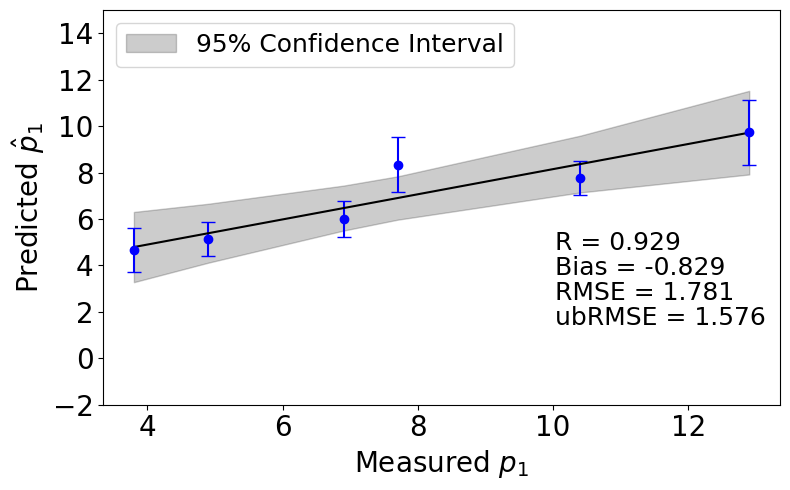

In [37]:
# Mean of predictions
mean_1 = np.mean(ExpTest_Pred[0:50,0])
mean_2 = np.mean(ExpTest_Pred[150:200,0])
mean_3 = np.mean(ExpTest_Pred[300:350,0])
mean_4 = np.mean(ExpTest_Pred[450:500,0])
mean_5 = np.mean(ExpTest_Pred[600:650,0])
mean_6 = np.mean(ExpTest_Pred[750:800,0])

# Standard deviation of predictions
std_1 = np.std(ExpTest_Pred[0:50,0])
std_2 = np.std(ExpTest_Pred[150:200,0])
std_3 = np.std(ExpTest_Pred[300:350,0])
std_4 = np.std(ExpTest_Pred[450:500,0])
std_5 = np.std(ExpTest_Pred[600:650,0])
std_6 = np.std(ExpTest_Pred[750:800,0])

pred_mean = np.array([mean_1,mean_2,mean_3,mean_4,mean_5,mean_6])
std_mean = np.array([std_1,std_2,std_3,std_4,std_5,std_6])
label = np.array([ExpTest_Label[0,0],ExpTest_Label[150,0],ExpTest_Label[300,0],ExpTest_Label[450,0],ExpTest_Label[600,0],ExpTest_Label[750,0]])

# R
R = np.corrcoef(label,pred_mean)[0,1]
print('p1 R on experimental tesing dataset: %.10f' % (R))

# Bias
Bias = np.mean(pred_mean) - np.mean(label)
print('p1 Bias on experimental tesing dataset: %.10f' % (Bias))

# MSE
MSE = np.mean((pred_mean - label) ** 2)
print('p1 MSE on experimental tesing dataset: %.10f' % (MSE))

# RMSE
RMSE = np.sqrt(MSE)
print('p1 RMSE on experimental tesing dataset: %.10f' % (RMSE))

# ubRMSE
ubRMSE = np.sqrt((RMSE ** 2 - Bias ** 2))
print('p1 ubMSE on experimental tesing dataset: %.10f' % (ubRMSE))

# Error bar plots
fig = plt.figure(figsize=(8, 5))
plt.errorbar(label, pred_mean, yerr=std_mean, fmt='o', color='b', capsize=5)

# Fit the OLS model
label_ = sm.add_constant(label)
OLSmodel = sm.OLS(pred_mean, label_)
results = OLSmodel.fit()
predictions = results.get_prediction(label_)
summary_frame = predictions.summary_frame(alpha=0.05) # 95% confidence level

# Confidence interval for the mean response
ci_lower = summary_frame['mean_ci_lower']
ci_upper = summary_frame['mean_ci_upper']

# Prediction interval for individual observations
pi_lower = summary_frame['obs_ci_lower']
pi_upper = summary_frame['obs_ci_upper']

plt.plot(label, results.predict(label_), color='black')
# plt.scatter(ExpTest_Label_Pro_p1, ExpTest_Pred_Pro_p1)

# Plotting the Confidence Interval (CI)
plt.fill_between(label, ci_lower, ci_upper, color='black', alpha=0.2, label='95% Confidence Interval')

plt.xlabel('Measured $p_1$',fontsize=20)
plt.ylabel('Predicted $\hat{p}_1$',fontsize=20)
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)
plt.figtext(0.70, 0.49, f'R = %.3f' % R, fontsize=18)
plt.figtext(0.70, 0.44, f'Bias = %.3f' % Bias, fontsize=18)
plt.figtext(0.70, 0.39, f'RMSE = %.3f' % RMSE, fontsize=18)
plt.figtext(0.70, 0.34, f'ubRMSE = %.3f' % ubRMSE, fontsize=18)
# plt.figtext(0.15, 0.70, f'Bias = %.3f' % results.params[0], fontsize=14)
plt.legend(fontsize=18, loc='upper left')
plt.ylim([-2,15])
plt.tight_layout()
fig.savefig('./TwoLayer_SoilPermittivity_1_CNN.png', dpi=600)
plt.show()

p1 R on experimental tesing dataset: 0.9504303475
p1 Bias on experimental tesing dataset: -0.1202707124
p1 MSE on experimental tesing dataset: 3.0463717947
p1 RMSE on experimental tesing dataset: 1.7453858584
p1 ubMSE on experimental tesing dataset: 1.7412371322


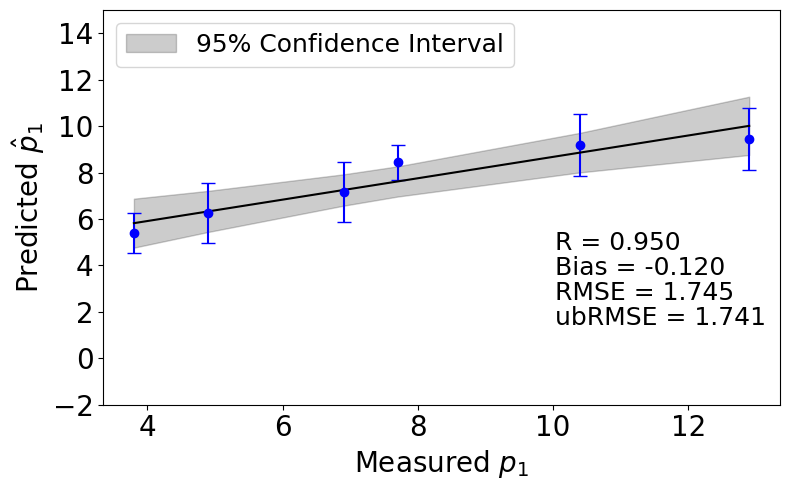

In [38]:
# Mean of predictions
mean_1 = np.mean(ExpTest_Pred[50:100,0])
mean_2 = np.mean(ExpTest_Pred[200:250,0])
mean_3 = np.mean(ExpTest_Pred[350:400,0])
mean_4 = np.mean(ExpTest_Pred[500:550,0])
mean_5 = np.mean(ExpTest_Pred[650:700,0])
mean_6 = np.mean(ExpTest_Pred[800:850,0])

# Standard deviation of predictions
std_1 = np.std(ExpTest_Pred[50:100,0])
std_2 = np.std(ExpTest_Pred[200:250,0])
std_3 = np.std(ExpTest_Pred[350:400,0])
std_4 = np.std(ExpTest_Pred[500:550,0])
std_5 = np.std(ExpTest_Pred[650:700,0])
std_6 = np.std(ExpTest_Pred[800:850,0])

pred_mean = np.array([mean_1,mean_2,mean_3,mean_4,mean_5,mean_6])
std_mean = np.array([std_1,std_2,std_3,std_4,std_5,std_6])
label = np.array([ExpTest_Label[0,0],ExpTest_Label[150,0],ExpTest_Label[300,0],ExpTest_Label[450,0],ExpTest_Label[600,0],ExpTest_Label[750,0]])

# R
R = np.corrcoef(label,pred_mean)[0,1]
print('p1 R on experimental tesing dataset: %.10f' % (R))

# Bias
Bias = np.mean(pred_mean) - np.mean(label)
print('p1 Bias on experimental tesing dataset: %.10f' % (Bias))

# MSE
MSE = np.mean((pred_mean - label) ** 2)
print('p1 MSE on experimental tesing dataset: %.10f' % (MSE))

# RMSE
RMSE = np.sqrt(MSE)
print('p1 RMSE on experimental tesing dataset: %.10f' % (RMSE))

# ubRMSE
ubRMSE = np.sqrt((RMSE ** 2 - Bias ** 2))
print('p1 ubMSE on experimental tesing dataset: %.10f' % (ubRMSE))

# Error bar plots
fig = plt.figure(figsize=(8, 5))
plt.errorbar(label, pred_mean, yerr=std_mean, fmt='o', color='b', capsize=5)

# Fit the OLS model
label_ = sm.add_constant(label)
OLSmodel = sm.OLS(pred_mean, label_)
results = OLSmodel.fit()
predictions = results.get_prediction(label_)
summary_frame = predictions.summary_frame(alpha=0.05) # 95% confidence level

# Confidence interval for the mean response
ci_lower = summary_frame['mean_ci_lower']
ci_upper = summary_frame['mean_ci_upper']

# Prediction interval for individual observations
pi_lower = summary_frame['obs_ci_lower']
pi_upper = summary_frame['obs_ci_upper']

plt.plot(label, results.predict(label_), color='black')
# plt.scatter(ExpTest_Label_Pro_p1, ExpTest_Pred_Pro_p1)

# Plotting the Confidence Interval (CI)
plt.fill_between(label, ci_lower, ci_upper, color='black', alpha=0.2, label='95% Confidence Interval')

plt.xlabel('Measured $p_1$',fontsize=20)
plt.ylabel('Predicted $\hat{p}_1$',fontsize=20)
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)
plt.figtext(0.70, 0.49, f'R = %.3f' % R, fontsize=18)
plt.figtext(0.70, 0.44, f'Bias = %.3f' % Bias, fontsize=18)
plt.figtext(0.70, 0.39, f'RMSE = %.3f' % RMSE, fontsize=18)
plt.figtext(0.70, 0.34, f'ubRMSE = %.3f' % ubRMSE, fontsize=18)
# plt.figtext(0.15, 0.70, f'Bias = %.3f' % results.params[0], fontsize=14)
plt.legend(fontsize=18, loc='upper left')
plt.ylim([-2,15])
plt.tight_layout()
fig.savefig('./TwoLayer_SoilPermittivity_2_CNN.png', dpi=600)
plt.show()

p1 R on experimental tesing dataset: 0.9068226685
p1 Bias on experimental tesing dataset: 0.3457135566
p1 MSE on experimental tesing dataset: 2.0099026161
p1 RMSE on experimental tesing dataset: 1.4177103428
p1 ubMSE on experimental tesing dataset: 1.3749126346


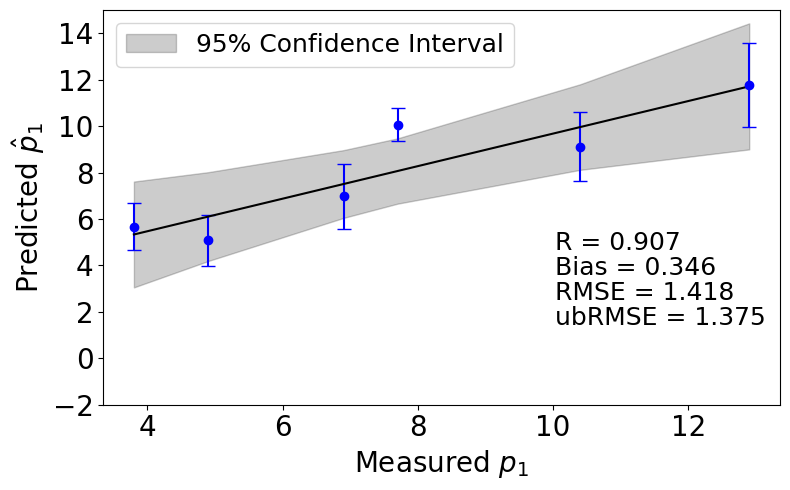

In [39]:
# Mean of predictions
mean_1 = np.mean(ExpTest_Pred[100:150,0])
mean_2 = np.mean(ExpTest_Pred[250:300,0])
mean_3 = np.mean(ExpTest_Pred[400:450,0])
mean_4 = np.mean(ExpTest_Pred[550:600,0])
mean_5 = np.mean(ExpTest_Pred[700:750,0])
mean_6 = np.mean(ExpTest_Pred[850:900,0])

# Standard deviation of predictions
std_1 = np.std(ExpTest_Pred[100:150,0])
std_2 = np.std(ExpTest_Pred[250:300,0])
std_3 = np.std(ExpTest_Pred[400:450,0])
std_4 = np.std(ExpTest_Pred[550:600,0])
std_5 = np.std(ExpTest_Pred[700:750,0])
std_6 = np.std(ExpTest_Pred[850:900,0])

pred_mean = np.array([mean_1,mean_2,mean_3,mean_4,mean_5,mean_6])
std_mean = np.array([std_1,std_2,std_3,std_4,std_5,std_6])
label = np.array([ExpTest_Label[0,0],ExpTest_Label[150,0],ExpTest_Label[300,0],ExpTest_Label[450,0],ExpTest_Label[600,0],ExpTest_Label[750,0]])

# R
R = np.corrcoef(label,pred_mean)[0,1]
print('p1 R on experimental tesing dataset: %.10f' % (R))

# Bias
Bias = np.mean(pred_mean) - np.mean(label)
print('p1 Bias on experimental tesing dataset: %.10f' % (Bias))

# MSE
MSE = np.mean((pred_mean - label) ** 2)
print('p1 MSE on experimental tesing dataset: %.10f' % (MSE))

# RMSE
RMSE = np.sqrt(MSE)
print('p1 RMSE on experimental tesing dataset: %.10f' % (RMSE))

# ubRMSE
ubRMSE = np.sqrt((RMSE ** 2 - Bias ** 2))
print('p1 ubMSE on experimental tesing dataset: %.10f' % (ubRMSE))

# Error bar plots
fig = plt.figure(figsize=(8, 5))
plt.errorbar(label, pred_mean, yerr=std_mean, fmt='o', color='b', capsize=5)

# Fit the OLS model
label_ = sm.add_constant(label)
OLSmodel = sm.OLS(pred_mean, label_)
results = OLSmodel.fit()
predictions = results.get_prediction(label_)
summary_frame = predictions.summary_frame(alpha=0.05) # 95% confidence level

# Confidence interval for the mean response
ci_lower = summary_frame['mean_ci_lower']
ci_upper = summary_frame['mean_ci_upper']

# Prediction interval for individual observations
pi_lower = summary_frame['obs_ci_lower']
pi_upper = summary_frame['obs_ci_upper']

plt.plot(label, results.predict(label_), color='black')
# plt.scatter(ExpTest_Label_Pro_p1, ExpTest_Pred_Pro_p1)

# Plotting the Confidence Interval (CI)
plt.fill_between(label, ci_lower, ci_upper, color='black', alpha=0.2, label='95% Confidence Interval')

plt.xlabel('Measured $p_1$',fontsize=20)
plt.ylabel('Predicted $\hat{p}_1$',fontsize=20)
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)
plt.figtext(0.70, 0.49, f'R = %.3f' % R, fontsize=18)
plt.figtext(0.70, 0.44, f'Bias = %.3f' % Bias, fontsize=18)
plt.figtext(0.70, 0.39, f'RMSE = %.3f' % RMSE, fontsize=18)
plt.figtext(0.70, 0.34, f'ubRMSE = %.3f' % ubRMSE, fontsize=18)
# plt.figtext(0.15, 0.70, f'Bias = %.3f' % results.params[0], fontsize=14)
plt.legend(fontsize=18, loc='upper left')
plt.ylim([-2,15])
plt.tight_layout()
fig.savefig('./TwoLayer_SoilPermittivity_3_CNN.png', dpi=600)
plt.show()

### Soil conductivity

In [40]:
specimen_1_pred_mean_c1 = np.mean(ExpTest_Pred[0:150,1])
specimen_2_pred_mean_c1 = np.mean(ExpTest_Pred[150:300,1])
specimen_3_pred_mean_c1 = np.mean(ExpTest_Pred[300:450,1])
specimen_4_pred_mean_c1 = np.mean(ExpTest_Pred[450:600,1])
specimen_5_pred_mean_c1 = np.mean(ExpTest_Pred[600:750,1])
specimen_6_pred_mean_c1 = np.mean(ExpTest_Pred[750:900,1])
ExpTest_Pred_Pro_c1 = np.array([specimen_1_pred_mean_c1,specimen_2_pred_mean_c1,specimen_3_pred_mean_c1,
                                    specimen_4_pred_mean_c1,specimen_5_pred_mean_c1,specimen_6_pred_mean_c1])
ExpTest_Label_Pro_c1 = np.array([ExpTest_Label[0,1],ExpTest_Label[150,1],ExpTest_Label[300,1],
                                    ExpTest_Label[450,1],ExpTest_Label[600,1],ExpTest_Label[750,1]])

In [41]:
# R^2
ExpTest_R2_c1 = r2_score(ExpTest_Label_Pro_c1,ExpTest_Pred_Pro_c1)
print('c1 R2 on experimental tesing dataset: %.10f' % (ExpTest_R2_c1))

# Mean square error
ExpTest_MSE_c1 = np.mean((ExpTest_Pred_Pro_c1 - ExpTest_Label_Pro_c1) ** 2)
print('c1 MSE on experimental tesing dataset: %.10f' % (ExpTest_MSE_c1))

# R
ExpTest_R_c1 = np.corrcoef(ExpTest_Label_Pro_c1,ExpTest_Pred_Pro_c1)[0,1]
print('c1 R on experimental tesing dataset: %.10f' % (ExpTest_R_c1))

# Bias
ExpTest_Bias_c1 = np.mean(ExpTest_Pred_Pro_c1) - np.mean(ExpTest_Label_Pro_c1)
print('c1 Bias on experimental tesing dataset: %.10f' % (ExpTest_Bias_c1))

c1 R2 on experimental tesing dataset: -0.5871351289
c1 MSE on experimental tesing dataset: 0.0023494661
c1 R on experimental tesing dataset: 0.7935434220
c1 Bias on experimental tesing dataset: -0.0378292443


c1 R on experimental tesing dataset: 0.7935434220
c1 Bias on experimental tesing dataset: -0.0378292443
c1 MSE on experimental tesing dataset: 0.0023494661
c1 RMSE on experimental tesing dataset: 0.0484712916
c1 ubMSE on experimental tesing dataset: 0.0303053525


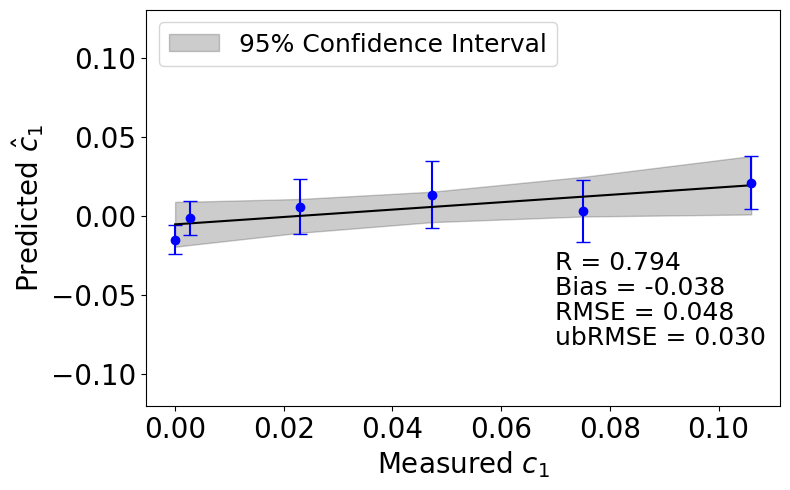

In [42]:
# Mean of predictions
mean_1 = np.mean(ExpTest_Pred[0:150,1])
mean_2 = np.mean(ExpTest_Pred[150:300,1])
mean_3 = np.mean(ExpTest_Pred[300:450,1])
mean_4 = np.mean(ExpTest_Pred[450:600,1])
mean_5 = np.mean(ExpTest_Pred[600:750,1])
mean_6 = np.mean(ExpTest_Pred[750:900,1])

# Standard deviation of predictions
std_1 = np.std(ExpTest_Pred[0:150,1])
std_2 = np.std(ExpTest_Pred[150:300,1])
std_3 = np.std(ExpTest_Pred[300:450,1])
std_4 = np.std(ExpTest_Pred[450:600,1])
std_5 = np.std(ExpTest_Pred[600:750,1])
std_6 = np.std(ExpTest_Pred[750:900,1])

pred_mean = np.array([mean_1,mean_2,mean_3,mean_4,mean_5,mean_6])
std_mean = np.array([std_1,std_2,std_3,std_4,std_5,std_6])
label = np.array([ExpTest_Label[0,1],ExpTest_Label[150,1],ExpTest_Label[300,1],ExpTest_Label[450,1],ExpTest_Label[600,1],ExpTest_Label[750,1]])

# R
R = np.corrcoef(label,pred_mean)[0,1]
print('c1 R on experimental tesing dataset: %.10f' % (R))

# Bias
Bias = np.mean(pred_mean) - np.mean(label)
print('c1 Bias on experimental tesing dataset: %.10f' % (Bias))

# MSE
MSE = np.mean((pred_mean - label) ** 2)
print('c1 MSE on experimental tesing dataset: %.10f' % (MSE))

# RMSE
RMSE = np.sqrt(MSE)
print('c1 RMSE on experimental tesing dataset: %.10f' % (RMSE))

# ubRMSE
ubRMSE = np.sqrt((RMSE ** 2 - Bias ** 2))
print('c1 ubMSE on experimental tesing dataset: %.10f' % (ubRMSE))

# Error bar plots
fig = plt.figure(figsize=(8, 5))
plt.errorbar(label, pred_mean, yerr=std_mean, fmt='o', color='b', capsize=5)

# Fit the OLS model
label_ = sm.add_constant(label)
OLSmodel = sm.OLS(pred_mean, label_)
results = OLSmodel.fit()
predictions = results.get_prediction(label_)
summary_frame = predictions.summary_frame(alpha=0.05) # 95% confidence level

# Confidence interval for the mean response
ci_lower = summary_frame['mean_ci_lower']
ci_upper = summary_frame['mean_ci_upper']

# Prediction interval for individual observations
pi_lower = summary_frame['obs_ci_lower']
pi_upper = summary_frame['obs_ci_upper']

plt.plot(label, results.predict(label_), color='black')
# plt.scatter(ExpTest_Label_Pro_p1, ExpTest_Pred_Pro_p1)

# Plotting the Confidence Interval (CI)
plt.fill_between(label, ci_lower, ci_upper, color='black', alpha=0.2, label='95% Confidence Interval')

plt.xlabel('Measured $c_1$',fontsize=20)
plt.ylabel('Predicted $\hat{c}_1$',fontsize=20)
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)
plt.figtext(0.70, 0.45, f'R = %.3f' % R, fontsize=18)
plt.figtext(0.70, 0.40, f'Bias = %.3f' % Bias, fontsize=18)
plt.figtext(0.70, 0.35, f'RMSE = %.3f' % RMSE, fontsize=18)
plt.figtext(0.70, 0.30, f'ubRMSE = %.3f' % ubRMSE, fontsize=18)
# plt.figtext(0.15, 0.70, f'Bias = %.3f' % results.params[0], fontsize=14)
plt.legend(fontsize=18, loc='upper left')
plt.ylim([-0.12,0.13])
plt.tight_layout()
fig.savefig('./TwoLayer_SoilConductivity_CNN.png', dpi=600)
plt.show()

### Straw permittivity

In [43]:
specimen_1_pred_mean_p2 = np.mean(np.concatenate([ExpTest_Pred[0:100,2],ExpTest_Pred[150:250,2],ExpTest_Pred[300:400,2],ExpTest_Pred[450:550,2],
                                                 ExpTest_Pred[600:700,2],ExpTest_Pred[750:850,2]],axis=0))
specimen_2_pred_mean_p2 = np.mean(np.concatenate([ExpTest_Pred[100:150,2],ExpTest_Pred[250:300,2],ExpTest_Pred[400:450,2],ExpTest_Pred[550:600,2],
                                                 ExpTest_Pred[700:750,2],ExpTest_Pred[850:900,2]],axis=0))
ExpTest_Pred_Pro_p2 = np.array([specimen_1_pred_mean_p2,specimen_2_pred_mean_p2])
ExpTest_Label_Pro_p2 = np.array([ExpTest_Label[0,2],ExpTest_Label[100,2]])

In [44]:
# R^2
ExpTest_R2_p2 = r2_score(ExpTest_Label_Pro_p2,ExpTest_Pred_Pro_p2)
print('p2 R2 on experimental tesing dataset: %.10f' % (ExpTest_R2_p2))

# Mean square error
ExpTest_MSE_p2 = np.mean((ExpTest_Pred_Pro_p2 - ExpTest_Label_Pro_p2) ** 2)
print('p2 MSE on experimental tesing dataset: %.10f' % (ExpTest_MSE_p2))

# R
ExpTest_R_p2 = np.corrcoef(ExpTest_Label_Pro_p2,ExpTest_Pred_Pro_p2)[0,1]
print('p2 R on experimental tesing dataset: %.10f' % (ExpTest_R_p2))

# Bias
ExpTest_Bias_p2 = np.mean(ExpTest_Pred_Pro_p2) - np.mean(ExpTest_Label_Pro_p2)
print('p2 Bias on experimental tesing dataset: %.10f' % (ExpTest_Bias_p2))

# RMSE
ExpTest_RMSE_p2 = np.sqrt(ExpTest_MSE_p2)
print('p2 RMSE on experimental tesing dataset: %.10f' % (ExpTest_RMSE_p2))

# ubRMSE
ExpTest_ubRMSE_p2 = np.sqrt((ExpTest_RMSE_p2 ** 2 - ExpTest_Bias_p2 ** 2))
print('p2 ubMSE on experimental tesing dataset: %.10f' % (ExpTest_ubRMSE_p2))

p2 R2 on experimental tesing dataset: -1.0224783792
p2 MSE on experimental tesing dataset: 0.7280922165
p2 R on experimental tesing dataset: 1.0000000000
p2 Bias on experimental tesing dataset: -0.6411374181
p2 RMSE on experimental tesing dataset: 0.8532831983
p2 ubMSE on experimental tesing dataset: 0.5630586361


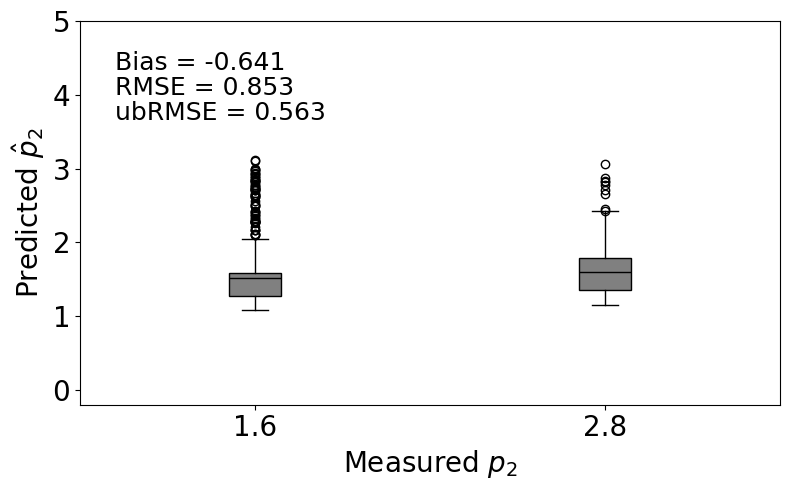

In [45]:
pred_1 = np.concatenate([ExpTest_Pred[0:100,2],ExpTest_Pred[150:250,2],ExpTest_Pred[300:400,2],ExpTest_Pred[450:550,2],
                               ExpTest_Pred[600:700,2],ExpTest_Pred[750:850,2]],axis=0)
pred_2 = np.concatenate([ExpTest_Pred[100:150,2],ExpTest_Pred[250:300,2],ExpTest_Pred[400:450,2],ExpTest_Pred[550:600,2],
                               ExpTest_Pred[700:750,2],ExpTest_Pred[850:900,2]],axis=0)

# Box plot
fig = plt.figure(figsize=(8, 5))
box = plt.boxplot([pred_1,pred_2],patch_artist=True,meanline=True,showmeans=True)
colors = ['gray','gray']
# fill with colors
for patch, color in zip(box['boxes'], colors):
    patch.set_facecolor(color)
for mean in box['means']:
    mean.set_color('black')
    mean.set_linestyle('solid')
for median in box['medians']:
    median.set_linewidth(0)

plt.xlabel('Measured $p_2$',fontsize=20)
plt.ylabel('Predicted $\hat{p}_2$',fontsize=20)
labels = ['1.6', '2.8']
plt.xticks([1, 2], labels, fontsize=20)
plt.yticks(fontsize=20)
plt.ylim([-0.2,5])
plt.figtext(0.15, 0.85, f'Bias = %.3f' % ExpTest_Bias_p2, fontsize=18)
plt.figtext(0.15, 0.80, f'RMSE = %.3f' % ExpTest_RMSE_p2, fontsize=18)
plt.figtext(0.15, 0.75, f'ubRMSE = %.3f' % ExpTest_ubRMSE_p2, fontsize=18)
plt.tight_layout()
fig.savefig('./TwoLayer_WSPermittivity_CNN.png', dpi=600)
plt.show()

### Straw conductivity

In [46]:
specimen_1_pred_mean_c2 = np.mean(np.concatenate([ExpTest_Pred[0:100,3],ExpTest_Pred[150:250,3],ExpTest_Pred[300:400,3],ExpTest_Pred[450:550,3],
                                                 ExpTest_Pred[600:700,3],ExpTest_Pred[750:850,3]],axis=0))
specimen_2_pred_mean_c2 = np.mean(np.concatenate([ExpTest_Pred[100:150,3],ExpTest_Pred[250:300,3],ExpTest_Pred[400:450,3],ExpTest_Pred[550:600,3],
                                                 ExpTest_Pred[700:750,3],ExpTest_Pred[850:900,3]],axis=0))
ExpTest_Pred_Pro_c2 = np.array([specimen_1_pred_mean_c2,specimen_2_pred_mean_c2])
ExpTest_Label_Pro_c2 = np.array([ExpTest_Label[0,3],ExpTest_Label[100,3]])

In [47]:
# R^2
ExpTest_R2_c2 = r2_score(ExpTest_Label_Pro_c2,ExpTest_Pred_Pro_c2)
print('c2 R2 on experimental tesing dataset: %.10f' % (ExpTest_R2_c2))

# Mean square error
ExpTest_MSE_c2 = np.mean((ExpTest_Pred_Pro_c2 - ExpTest_Label_Pro_c2) ** 2)
print('c2 MSE on experimental tesing dataset: %.10f' % (ExpTest_MSE_c2))

# R
ExpTest_R_c2 = np.corrcoef(ExpTest_Label_Pro_c2,ExpTest_Pred_Pro_c2)[0,1]
print('c2 R on experimental tesing dataset: %.10f' % (ExpTest_R_c2))

# Bias
ExpTest_Bias_c2 = np.mean(ExpTest_Pred_Pro_c2) - np.mean(ExpTest_Label_Pro_c2)
print('c2 Bias on experimental tesing dataset: %.10f' % (ExpTest_Bias_c2))

# RMSE
ExpTest_RMSE_c2 = np.sqrt(ExpTest_MSE_c2)
print('c2 RMSE on experimental tesing dataset: %.10f' % (ExpTest_RMSE_c2))

# ubRMSE
ExpTest_ubRMSE_c2 = np.sqrt((ExpTest_RMSE_c2 ** 2 - ExpTest_Bias_c2 ** 2))
print('c2 ubMSE on experimental tesing dataset: %.10f' % (ExpTest_ubRMSE_c2))

c2 R2 on experimental tesing dataset: 0.0000000000
c2 MSE on experimental tesing dataset: 0.0000011986
c2 R on experimental tesing dataset: nan
c2 Bias on experimental tesing dataset: -0.0010882949
c2 RMSE on experimental tesing dataset: 0.0010947921
c2 ubMSE on experimental tesing dataset: 0.0001190964


c:\Users\wangz\anaconda3\envs\pytorch\lib\site-packages\numpy\lib\function_base.py:2897: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
c:\Users\wangz\anaconda3\envs\pytorch\lib\site-packages\numpy\lib\function_base.py:2898: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


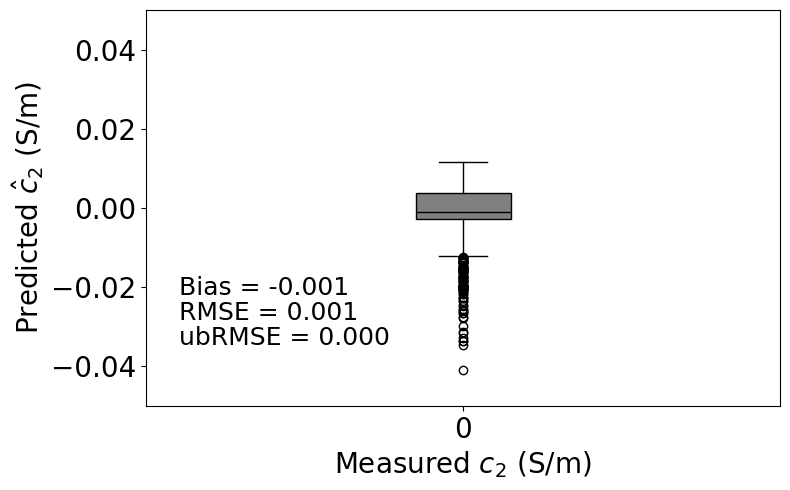

In [48]:
# Box plot
fig = plt.figure(figsize=(8, 5))
box = plt.boxplot(ExpTest_Pred[:,3],patch_artist=True,meanline=True,showmeans=True)
colors = ['gray']
# fill with colors
for patch, color in zip(box['boxes'], colors):
    patch.set_facecolor(color)
for mean in box['means']:
    mean.set_color('black')
    mean.set_linestyle('solid')
for median in box['medians']:
    median.set_linewidth(0)

plt.xlabel('Measured $c_2$ (S/m)',fontsize=20)
plt.ylabel('Predicted $\hat{c}_2$ (S/m)',fontsize=20)
labels = ['0']
plt.xticks([1], labels, fontsize=20)
plt.yticks(fontsize=20)
plt.ylim([-0.05,0.05])
plt.figtext(0.23, 0.40, f'Bias = %.3f' % ExpTest_Bias_c2, fontsize=18)
plt.figtext(0.23, 0.35, f'RMSE = %.3f' % ExpTest_RMSE_c2, fontsize=18)
plt.figtext(0.23, 0.30, f'ubRMSE = %.3f' % ExpTest_ubRMSE_c2, fontsize=18)
plt.tight_layout()
fig.savefig('./TwoLayer_WSConductivity_CNN.png', dpi=600)
plt.show()

### Straw depth

In [49]:
specimen_1_pred_mean_d2 = np.mean(np.concatenate([ExpTest_Pred[0:50,4],ExpTest_Pred[100:200,4],ExpTest_Pred[250:350,4],ExpTest_Pred[400:500,4],
                                                 ExpTest_Pred[550:650,4],ExpTest_Pred[700:800,4],ExpTest_Pred[850:900,4]],axis=0))
specimen_2_pred_mean_d2 = np.mean(np.concatenate([ExpTest_Pred[50:100,4],ExpTest_Pred[200:250,4],ExpTest_Pred[350:400,4],ExpTest_Pred[500:550,4],
                                                 ExpTest_Pred[650:700,4],ExpTest_Pred[800:850,4]],axis=0))
ExpTest_Pred_Pro_d2 = np.array([specimen_1_pred_mean_d2,specimen_2_pred_mean_d2])
ExpTest_Label_Pro_d2 = np.array([ExpTest_Label[0,4],ExpTest_Label[50,4]])

In [50]:
# R^2
ExpTest_R2_d2 = r2_score(ExpTest_Label_Pro_d2,ExpTest_Pred_Pro_d2)
print('d2 R2 on experimental tesing dataset: %.10f' % (ExpTest_R2_d2))

# Mean square error
ExpTest_MSE_d2 = np.mean((ExpTest_Pred_Pro_d2 - ExpTest_Label_Pro_d2) ** 2)
print('d2 MSE on experimental tesing dataset: %.10f' % (ExpTest_MSE_d2))

# R
ExpTest_R_d2 = np.corrcoef(ExpTest_Label_Pro_d2,ExpTest_Pred_Pro_d2)[0,1]
print('d2 R on experimental tesing dataset: %.10f' % (ExpTest_R_d2))

# Bias
ExpTest_Bias_d2 = np.mean(ExpTest_Pred_Pro_d2) - np.mean(ExpTest_Label_Pro_d2)
print('d2 Bias on experimental tesing dataset: %.10f' % (ExpTest_Bias_d2))

# RMSE
ExpTest_RMSE_d2 = np.sqrt(ExpTest_MSE_d2)
print('d2 RMSE on experimental tesing dataset: %.10f' % (ExpTest_RMSE_d2))

# ubRMSE
ExpTest_ubRMSE_d2 = np.sqrt((ExpTest_RMSE_d2 ** 2 - ExpTest_Bias_d2 ** 2))
print('d2 ubMSE on experimental tesing dataset: %.10f' % (ExpTest_ubRMSE_d2))

d2 R2 on experimental tesing dataset: -0.7565780898
d2 MSE on experimental tesing dataset: 0.0010978613
d2 R on experimental tesing dataset: 1.0000000000
d2 Bias on experimental tesing dataset: 0.0229224334
d2 RMSE on experimental tesing dataset: 0.0331339902
d2 ubMSE on experimental tesing dataset: 0.0239253705


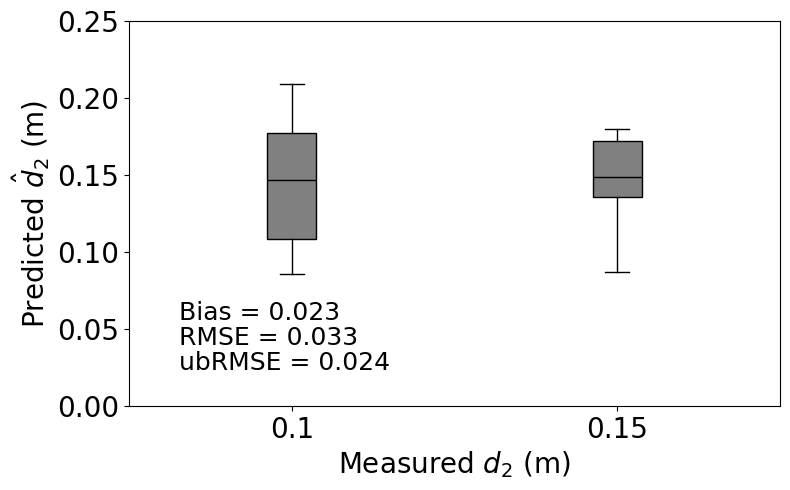

In [51]:
pred_1 = np.concatenate([ExpTest_Pred[0:50,4],ExpTest_Pred[100:200,4],ExpTest_Pred[250:350,4],ExpTest_Pred[400:500,4],
                               ExpTest_Pred[550:650,4],ExpTest_Pred[700:800,4],ExpTest_Pred[850:900,4]],axis=0)
pred_2 = np.concatenate([ExpTest_Pred[50:100,4],ExpTest_Pred[200:250,4],ExpTest_Pred[350:400,4],ExpTest_Pred[500:550,4],
                               ExpTest_Pred[650:700,4],ExpTest_Pred[800:850,4]],axis=0)

# Box plot
fig = plt.figure(figsize=(8, 5))
box = plt.boxplot([pred_1,pred_2],patch_artist=True,meanline=True,showmeans=True)
colors = ['gray','gray']
# fill with colors
for patch, color in zip(box['boxes'], colors):
    patch.set_facecolor(color)
for mean in box['means']:
    mean.set_color('black')
    mean.set_linestyle('solid')
for median in box['medians']:
    median.set_linewidth(0)

plt.xlabel('Measured $d_2$ (m)',fontsize=20)
plt.ylabel('Predicted $\hat{d}_2$ (m)',fontsize=20)
labels = ['0.1', '0.15']
plt.xticks([1, 2], labels, fontsize=20)
plt.yticks(fontsize=20)
plt.ylim([0,0.25])
plt.figtext(0.23, 0.35, f'Bias = %.3f' % ExpTest_Bias_d2, fontsize=18)
plt.figtext(0.23, 0.30, f'RMSE = %.3f' % ExpTest_RMSE_d2, fontsize=18)
plt.figtext(0.23, 0.25, f'ubRMSE = %.3f' % ExpTest_ubRMSE_d2, fontsize=18)
plt.tight_layout()
fig.savefig('./TwoLayer_WSDepth_CNN.png', dpi=600)
plt.show()